In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('data/sales_data.csv')
df.head()

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
0,2026-01-31,T1000,P006,Full Cream Milk 2L,Dairy,Sandton,9.0,34.0,Cash
1,2026-06-03,T1001,P010,Beef Mince 1kg,Meat,Pretoria,9.0,135.0,Mobile
2,2026-05-31,T1002,P008,Tomatoes 1kg,Produce,Sandton,4.0,30.0,Card
3,2026-01-29,T1003,P005,Cheddar Cheese 500g,Dairy,Sandton,14.0,95.0,Mobile
4,2026-01-03,T1004,P008,Tomatoes 1kg,Produce,Soweto,11.0,30.0,Cash


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            600 non-null    str    
 1   transaction_id  600 non-null    str    
 2   product_id      600 non-null    str    
 3   product_name    600 non-null    str    
 4   category        600 non-null    str    
 5   store           600 non-null    str    
 6   quantity        599 non-null    float64
 7   unit_price      600 non-null    str    
 8   payment_method  600 non-null    str    
dtypes: float64(1), str(8)
memory usage: 42.3 KB


In [4]:
df[pd.to_numeric(df['unit_price'], errors='coerce').isna()]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
42,2026-01-12,T1042,P009,Chicken Breasts 1kg,Meat,Sandton,15.0,unknown,Mobile


In [5]:
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df = df.dropna(subset=['unit_price'])
df.info()

<class 'pandas.DataFrame'>
Index: 599 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            599 non-null    str    
 1   transaction_id  599 non-null    str    
 2   product_id      599 non-null    str    
 3   product_name    599 non-null    str    
 4   category        599 non-null    str    
 5   store           599 non-null    str    
 6   quantity        598 non-null    float64
 7   unit_price      599 non-null    float64
 8   payment_method  599 non-null    str    
dtypes: float64(2), str(7)
memory usage: 46.8 KB


In [6]:
df[df['quantity'].isna()]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
15,2026-05-01,T1015,P003,Whole Wheat Bread,Bakery,Rosebank,NaN,28.0,Card


In [7]:
median_qty = df[df['product_name'] == 'Whole Wheat Bread']['quantity'].median()
df['quantity'] = df['quantity'].fillna(median_qty)
df.info()

<class 'pandas.DataFrame'>
Index: 599 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            599 non-null    str    
 1   transaction_id  599 non-null    str    
 2   product_id      599 non-null    str    
 3   product_name    599 non-null    str    
 4   category        599 non-null    str    
 5   store           599 non-null    str    
 6   quantity        599 non-null    float64
 7   unit_price      599 non-null    float64
 8   payment_method  599 non-null    str    
dtypes: float64(2), str(7)
memory usage: 46.8 KB


In [8]:
median_qty

np.float64(7.0)

In [9]:
df[df.duplicated(subset=['transaction_id'], keep=False)]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
87,2026-02-18,T1087,P003,Whole Wheat Bread,Bakery,Pretoria,11.0,28.0,Cash
88,2026-02-18,T1087,P003,Whole Wheat Bread,Bakery,Pretoria,11.0,28.0,Cash


In [10]:
df = df.drop_duplicates(subset=['transaction_id'], keep='first')
df.info()

<class 'pandas.DataFrame'>
Index: 598 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            598 non-null    str    
 1   transaction_id  598 non-null    str    
 2   product_id      598 non-null    str    
 3   product_name    598 non-null    str    
 4   category        598 non-null    str    
 5   store           598 non-null    str    
 6   quantity        598 non-null    float64
 7   unit_price      598 non-null    float64
 8   payment_method  598 non-null    str    
dtypes: float64(2), str(7)
memory usage: 46.7 KB


In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df[df['date'].isna()]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
120,NaT,T1120,P003,Whole Wheat Bread,Bakery,Soweto,1.0,28.0,EFT


In [12]:
raw = pd.read_csv('data/sales_data.csv')
bad_id = df[df['date'].isna()]['transaction_id'].values[0]
raw[raw['transaction_id'] == bad_id]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
120,03/15/2026,T1120,P003,Whole Wheat Bread,Bakery,Soweto,1.0,28.0,EFT


In [13]:
mask = df['date'].isna()
df.loc[mask, 'date'] = pd.to_datetime(raw.loc[mask, 'date'], format='%m/%d/%Y')
df.info()

AssertionError: 

In [14]:
df.loc[df['transaction_id'] == 'T1120', 'date'] = pd.to_datetime('03/15/2026', format='%m/%d/%Y')
df.info()

<class 'pandas.DataFrame'>
Index: 598 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            598 non-null    datetime64[us]
 1   transaction_id  598 non-null    str           
 2   product_id      598 non-null    str           
 3   product_name    598 non-null    str           
 4   category        598 non-null    str           
 5   store           598 non-null    str           
 6   quantity        598 non-null    float64       
 7   unit_price      598 non-null    float64       
 8   payment_method  598 non-null    str           
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 62.9 KB


In [15]:
df[df['quantity'] < 0]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
200,2026-02-12,T1200,P009,Chicken Breasts 1kg,Meat,Soweto,-3.0,120.0,Mobile


In [16]:
df['quantity'] = df['quantity'].abs()
df[df['quantity'] < 0]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method


In [17]:
print(df['category'].unique())
print(df['store'].unique())

<StringArray>
['Dairy', 'Meat', 'Produce', 'Beverages', 'Bakery', 'beverages']
Length: 6, dtype: str
<StringArray>
['Sandton', 'Pretoria', 'Soweto', 'Rosebank', '  soweto ']
Length: 5, dtype: str


In [19]:
df['category'] = df['category'].str.strip().str.title()
df['store'] = df['store'].str.strip().str.title()
print(df['category'].unique())
print(df['store'].unique())

<StringArray>
['Dairy', 'Meat', 'Produce', 'Beverages', 'Bakery']
Length: 5, dtype: str
<StringArray>
['Sandton', 'Pretoria', 'Soweto', 'Rosebank']
Length: 4, dtype: str


In [20]:
df['total_sale'] = df['quantity'] * df['unit_price']
df['total_sale'].sum()

np.float64(324859.0)

In [21]:
print(df['total_sale'].mean())
df.groupby('store')['total_sale'].sum().sort_values(ascending=False)

543.242474916388


store
Sandton     89137.5
Pretoria    84412.0
Soweto      83929.0
Rosebank    67380.5
Name: total_sale, dtype: float64

In [22]:
print(df.groupby('category')['total_sale'].sum().sort_values(ascending=False))
print(df.groupby('product_name')['total_sale'].sum().sort_values(ascending=False).head(5))

category
Beverages    109320.0
Meat         104415.0
Dairy         65604.0
Produce       22806.0
Bakery        22714.0
Name: total_sale, dtype: float64
product_name
Coffee Beans 1kg       77760.0
Chicken Breasts 1kg    53520.0
Beef Mince 1kg         50895.0
Cheddar Cheese 500g    46360.0
Rooibos Tea 100g       31350.0
Name: total_sale, dtype: float64


In [23]:
df['month'] = df['date'].dt.to_period('M')
print(df.groupby('month')['total_sale'].sum())
print(df['payment_method'].value_counts())

month
2026-01    44140.0
2026-02    47771.5
2026-03    37588.0
2026-04    57409.0
2026-05    77196.0
2026-06    58026.5
2026-07     2728.0
Freq: M, Name: total_sale, dtype: float64
payment_method
Mobile    167
Card      144
EFT       144
Cash      143
Name: count, dtype: int64


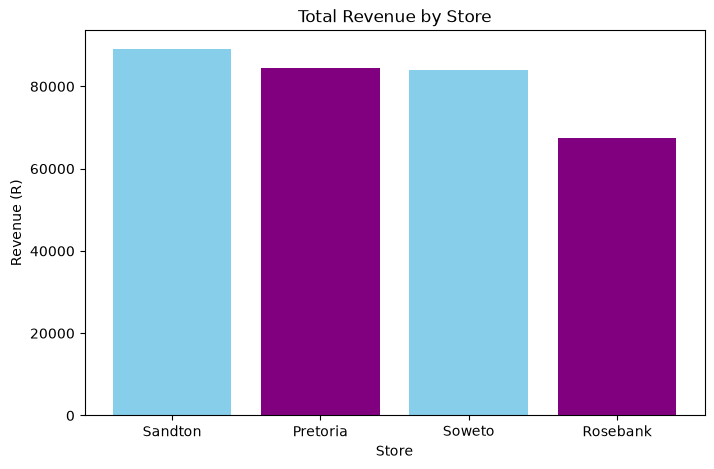

In [24]:
store_revenue = df.groupby('store')['total_sale'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(store_revenue.index, store_revenue.values, color=['skyblue', 'purple', 'skyblue', 'purple'])
plt.title('Total Revenue by Store')
plt.xlabel('Store')
plt.ylabel('Revenue (R)')
plt.savefig('charts/revenue_by_store.png')
plt.show()

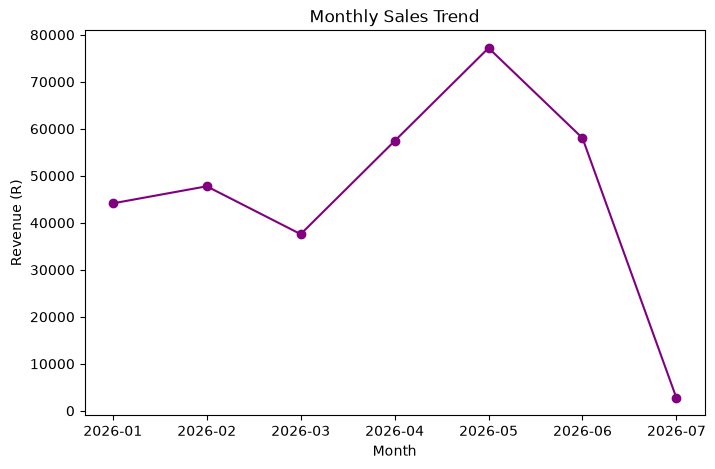

In [25]:
monthly_sales = df.groupby('month')['total_sale'].sum()

plt.figure(figsize=(8, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='purple')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (R)')
plt.savefig('charts/monthly_sales_trend.png')
plt.show()



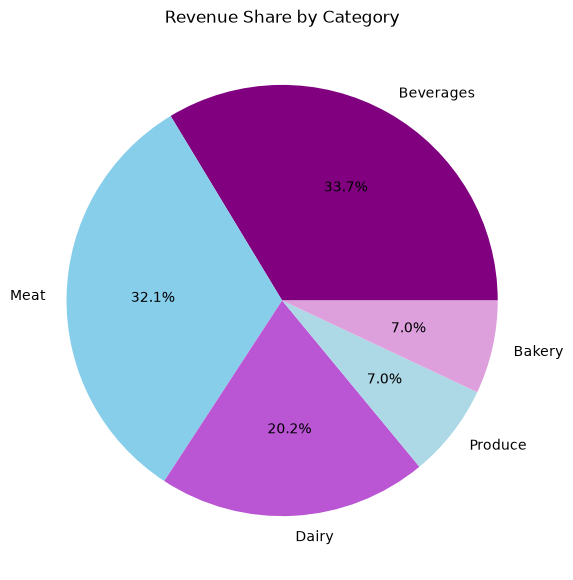

In [26]:
category_revenue = df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 7))
plt.pie(category_revenue.values, labels=category_revenue.index, autopct='%1.1f%%', colors=['purple', 'skyblue', 'mediumorchid', 'lightblue', 'plum'])
plt.title('Revenue Share by Category')
plt.savefig('charts/revenue_by_category.png')
plt.show()